# One-Class SVM

In [65]:
# Import libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

from sklearn.svm import OneClassSVM
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import average_precision_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer

import torch
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.datasets.folder import default_loader
import optuna
from sklearn.model_selection import train_test_split

## Part 1: Hazelnut Dataset

### Step 1.1: Feature Extraction Setup
Features are extracted using a pretrained CNN called Resnet 18 for efficiency.

In [66]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=True)
model = torch.nn.Sequential(*list(model.children())[:-1])  # Remove last FC layer
model.eval().to(device)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

def extract_deep_features(img_paths):
    features = []
    for path in tqdm(img_paths, desc="Extracting features"):
        img = default_loader(path)
        img = transform(img).unsqueeze(0).to(device)
        with torch.no_grad():
            feat = model(img).squeeze().cpu().numpy()
        features.append(feat)
    return features

c:\Users\Joyce\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Joyce\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


### Step 1.2: Load Train Features (good images only)

In [67]:
train_dir_hazelnut = r'C:\python-anomaly detection\hazelnut\train'
train_good_dir = os.path.join(train_dir_hazelnut, 'good')
train_paths = [os.path.join(train_good_dir, f) for f in os.listdir(train_good_dir) if f.endswith('.png')]
train_features_hazelnut = extract_deep_features(train_paths)

Extracting features: 100%|██████████| 391/391 [00:44<00:00,  8.73it/s]


### Step 1.3: Load Test Features and Labels

In [68]:
test_dir_hazelnut = r'C:\python-anomaly detection\hazelnut\test'
test_features_hazelnut = []
test_labels_hazelnut = []  # 1 for normal, -1 for anomaly
test_paths_hazelnut = []
img_paths_hazelnut = []

for subdir in os.listdir(test_dir_hazelnut):
    full_path = os.path.join(test_dir_hazelnut, subdir)
    label = 1 if subdir == 'good' else -1
    images = [os.path.join(full_path, f) for f in os.listdir(full_path) if f.endswith('.png')]
    feats = extract_deep_features(images)
    test_features_hazelnut.extend(feats)
    test_labels_hazelnut.extend([label] * len(images))
    test_paths_hazelnut.extend(images)
    img_paths_hazelnut.extend(images)

test_features_hazelnut = np.array(test_features_hazelnut)
test_labels_hazelnut = np.array(test_labels_hazelnut)

Extracting features: 100%|██████████| 17/17 [00:01<00:00,  8.87it/s]


In [69]:
# Split test set into Validation and Final Test
val_features_hazelnut, test_final_features_hazelnut, val_labels_hazelnut, test_final_labels_hazelnut, paths_val_hazelnut, paths_test_final_hazelnut = train_test_split(
    test_features_hazelnut, test_labels_hazelnut, test_paths_hazelnut,
    test_size=0.5,           
    stratify=test_labels_hazelnut,
    random_state=42
)

### Step 1.4: Predict and Evaluate

In [72]:
import numpy as np
import pandas as pd
from sklearn.svm import OneClassSVM
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, precision_recall_curve, auc
)

# Map original labels from (-1, +1) to (1, 0) with anomaly as 1 and normal as 0
true_bin = [1 if y == -1 else 0 for y in test_labels_hazelnut]

def evaluate_ocsvm(params, model_name="OC-SVM"):
    clf = OneClassSVM(**params)
    clf.fit(train_features_hazelnut)

    preds = clf.predict(test_features_hazelnut)          # +1 / -1
    preds_bin = [1 if p == -1 else 0 for p in preds]

    scores = -clf.decision_function(test_features_hazelnut)  # The larger the more anomalous

    precision, recall, _ = precision_recall_curve(true_bin, scores)
    pr_auc = auc(recall, precision)

    return {
        'Model':      model_name,
        'Accuracy':   accuracy_score(true_bin, preds_bin),
        'Precision':  precision_score(true_bin, preds_bin, zero_division=0),
        'Recall':     recall_score(true_bin, preds_bin),
        'F1 Score':   f1_score(true_bin, preds_bin),
        'ROC AUC':    roc_auc_score(true_bin, scores),
        'PR AUC':     pr_auc,
        'Params':     params,
        'Scores':     scores,
        'Model Obj':  clf
    }

# Prepare several parameter sets for comparing models
param_list_svm = [
    {'kernel': 'rbf', 'nu': 0.1, 'gamma': 'scale'},
    {'kernel': 'rbf', 'nu': 0.5,  'gamma': 'scale'},
    {'kernel': 'rbf', 'nu': 0.7,  'gamma': 'scale'},
    {'kernel': 'rbf', 'nu': 0.1,  'gamma': 0.01  },
    {'kernel': 'rbf', 'nu': 0.1,  'gamma': 0.001 },
]

results_hazelnut = []
for i, params in enumerate(param_list_svm, 1):
    res = evaluate_ocsvm(params, model_name=f"OC-SVM {i}")
    results_hazelnut.append(res)

# Display with dataframe
df_results_hazelnut = pd.DataFrame(results_hazelnut)
print(df_results_hazelnut[['Model','Accuracy','Precision','Recall','F1 Score','ROC AUC','PR AUC','Params']])

      Model  Accuracy  Precision    Recall  F1 Score   ROC AUC    PR AUC  \
0  OC-SVM 1  0.736364   0.955556  0.614286  0.747826  0.872500  0.929413   
1  OC-SVM 2  0.790909   0.776471  0.942857  0.851613  0.868571  0.928140   
2  OC-SVM 3  0.745455   0.718750  0.985714  0.831325  0.868571  0.927414   
3  OC-SVM 4  0.827273   0.932203  0.785714  0.852713  0.911429  0.951590   
4  OC-SVM 5  0.709091   0.952381  0.571429  0.714286  0.860357  0.922593   

                                           Params  
0  {'kernel': 'rbf', 'nu': 0.1, 'gamma': 'scale'}  
1  {'kernel': 'rbf', 'nu': 0.5, 'gamma': 'scale'}  
2  {'kernel': 'rbf', 'nu': 0.7, 'gamma': 'scale'}  
3     {'kernel': 'rbf', 'nu': 0.1, 'gamma': 0.01}  
4    {'kernel': 'rbf', 'nu': 0.1, 'gamma': 0.001}  


### Using Bayesian Optimization in Hyperparameter Tuning
This advanced technique builds a probabilistic model of the function mapping hyperparameters to a score, allowing for more efficient exploration of the hyperparameter space.

In [73]:
# Use Optuna selecting parameters (nu and gamma)
def objective(trial):
    params = {
        'kernel': 'rbf',
        'nu':    trial.suggest_float('nu',   0.001, 0.9),
        'gamma': trial.suggest_float('gamma', 0.0001, 0.1)
    }
    clf = OneClassSVM(**params)
    clf.fit(train_features_hazelnut)
    preds = clf.predict(val_features_hazelnut)
    preds_bin = [1 if p == -1 else 0 for p in preds]
    true_bin = [1 if y == -1 else 0 for y in val_labels_hazelnut]
    trial_f1_score = f1_score(true_bin, preds_bin)
    
    return trial_f1_score

sampler = optuna.samplers.TPESampler(seed=42)
study   = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective, n_trials=30)

print("Best hyperparameters by PR AUC:", study.best_params)
print("Best PR AUC on Validation:", study.best_value)


# Add model with Optuna parameter to results
# results_hazelnut = []  # Clear previous results if needed
best_result = evaluate_ocsvm(study.best_params, model_name="Optuna OC-SVM")
results_hazelnut.append(best_result)

[I 2025-05-04 17:46:24,476] A new study created in memory with name: no-name-1fdb7294-4a0d-40d2-bc98-8359c5820968
[I 2025-05-04 17:46:24,577] Trial 0 finished with value: 0.7777777777777778 and parameters: {'nu': 0.3377115668437789, 'gamma': 0.09507635921035062}. Best is trial 0 with value: 0.7777777777777778.
[I 2025-05-04 17:46:24,630] Trial 1 finished with value: 0.7777777777777778 and parameters: {'nu': 0.6590625536884532, 'gamma': 0.05990598257128396}. Best is trial 0 with value: 0.7777777777777778.
[I 2025-05-04 17:46:24,647] Trial 2 finished with value: 0.8857142857142857 and parameters: {'nu': 0.14126075775775043, 'gamma': 0.015683852581586645}. Best is trial 2 with value: 0.8857142857142857.
[I 2025-05-04 17:46:24,709] Trial 3 finished with value: 0.7777777777777778 and parameters: {'nu': 0.053217167339211315, 'gamma': 0.08663099696291603}. Best is trial 2 with value: 0.8857142857142857.
[I 2025-05-04 17:46:24,786] Trial 4 finished with value: 0.7777777777777778 and parameters

Best hyperparameters by PR AUC: {'nu': 0.21056824896035542, 'gamma': 0.023939412415279256}
Best PR AUC on Validation: 0.8860759493670886


In [74]:
results_df_hazelnut = pd.DataFrame(results_hazelnut)
print(results_df_hazelnut[['Model','Accuracy','Precision','Recall','F1 Score','ROC AUC','PR AUC','Params']])

           Model  Accuracy  Precision    Recall  F1 Score   ROC AUC    PR AUC  \
0       OC-SVM 1  0.736364   0.955556  0.614286  0.747826  0.872500  0.929413   
1       OC-SVM 2  0.790909   0.776471  0.942857  0.851613  0.868571  0.928140   
2       OC-SVM 3  0.745455   0.718750  0.985714  0.831325  0.868571  0.927414   
3       OC-SVM 4  0.827273   0.932203  0.785714  0.852713  0.911429  0.951590   
4       OC-SVM 5  0.709091   0.952381  0.571429  0.714286  0.860357  0.922593   
5  Optuna OC-SVM  0.800000   0.772727  0.971429  0.860759  0.941429  0.968850   

                                              Params  
0     {'kernel': 'rbf', 'nu': 0.1, 'gamma': 'scale'}  
1     {'kernel': 'rbf', 'nu': 0.5, 'gamma': 'scale'}  
2     {'kernel': 'rbf', 'nu': 0.7, 'gamma': 'scale'}  
3        {'kernel': 'rbf', 'nu': 0.1, 'gamma': 0.01}  
4       {'kernel': 'rbf', 'nu': 0.1, 'gamma': 0.001}  
5  {'nu': 0.21056824896035542, 'gamma': 0.0239394...  


### Step 1.5: Visualize Metrics & Compare Models

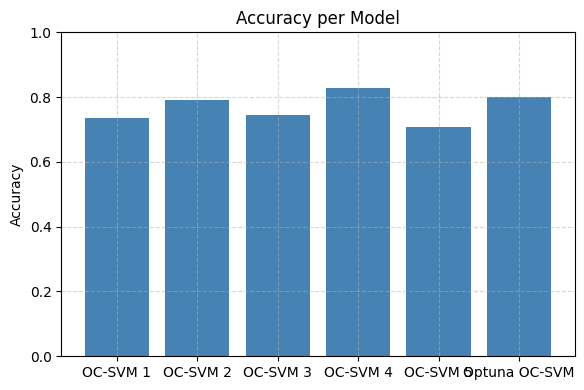

In [75]:
# Plot accuracy per Model
plt.figure(figsize=(6, 4))
plt.bar(results_df_hazelnut['Model'], results_df_hazelnut['Accuracy'], color='steelblue')
plt.title('Accuracy per Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

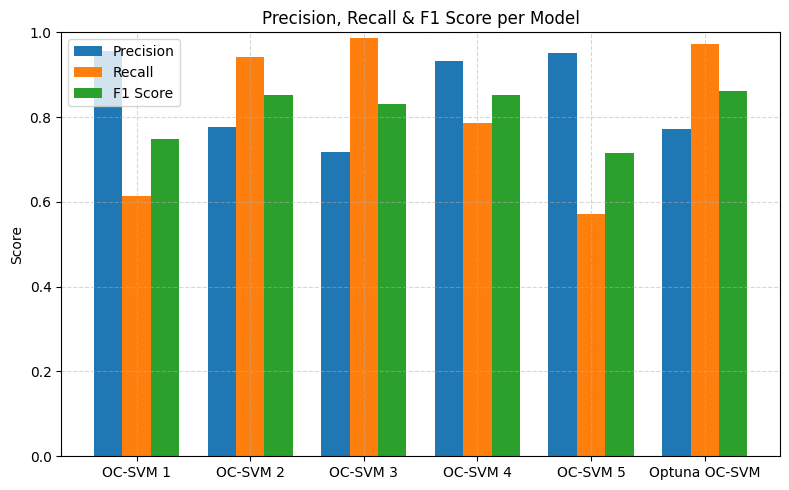

In [76]:
# Plot Precision Recall F1 per model
x = np.arange(len(results_df_hazelnut['Model']))
width = 0.25

plt.figure(figsize=(8, 5))
plt.bar(x - width, results_df_hazelnut['Precision'], width=width, label='Precision')
plt.bar(x, results_df_hazelnut['Recall'], width=width, label='Recall')
plt.bar(x + width, results_df_hazelnut['F1 Score'], width=width, label='F1 Score')

plt.xticks(x, results_df_hazelnut['Model'])
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Precision, Recall & F1 Score per Model')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

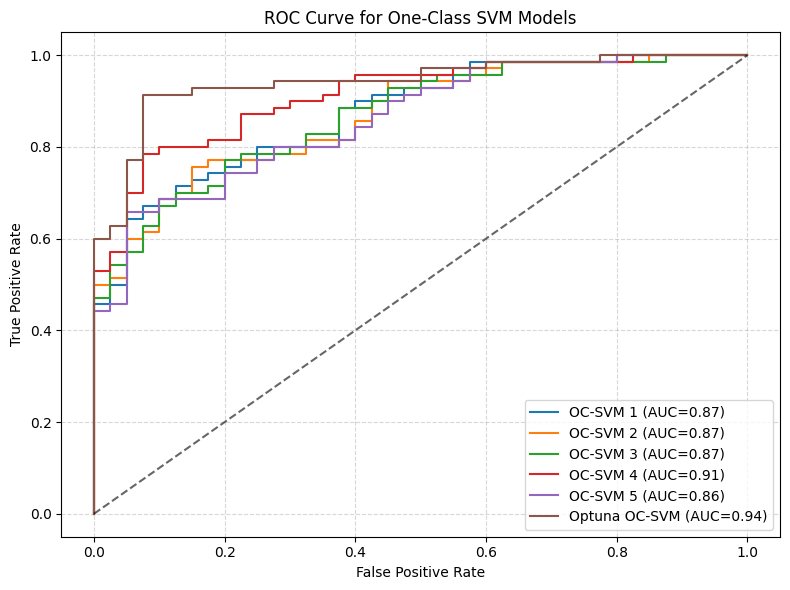

In [77]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import OneClassSVM
from sklearn.metrics import roc_curve, roc_auc_score

roc_curves = []

for idx, row in results_df_hazelnut.iterrows():
    params     = row['Params']      # {'nu':..., 'gamma':...}
    model_name = row['Model']       # e.g. "OC-SVM 1"

    clf = OneClassSVM(**params)
    clf.fit(train_features_hazelnut)

    scores = -clf.decision_function(test_features_hazelnut)

    fpr, tpr, _   = roc_curve(true_bin, scores)
    auc_score     = roc_auc_score(true_bin, scores)

    roc_curves.append((f"{model_name} (AUC={auc_score:.2f})", fpr, tpr))

# Plot ROC Curve for each model
plt.figure(figsize=(8, 6))
for label, fpr, tpr in roc_curves:
    plt.plot(fpr, tpr, label=label)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.6)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for One-Class SVM Models')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

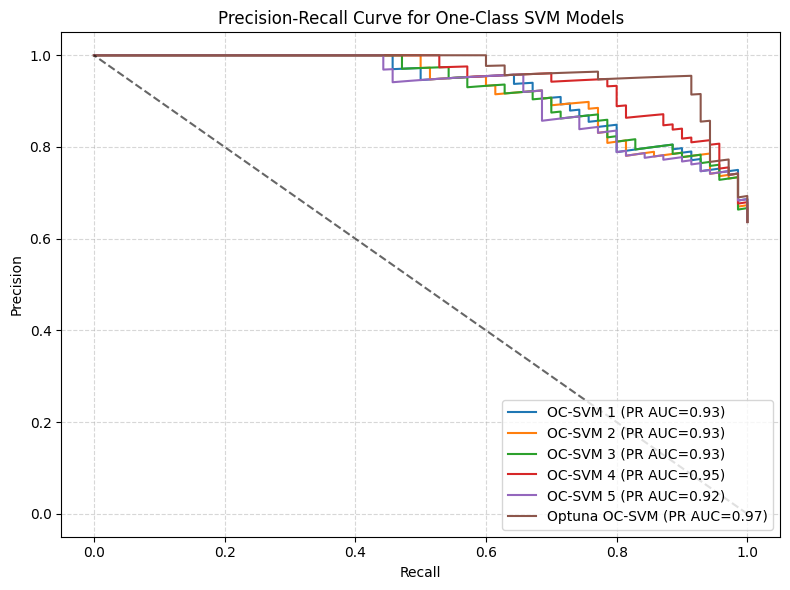

In [78]:
from sklearn.metrics import precision_recall_curve, average_precision_score

pr_curves = []

for idx, row in results_df_hazelnut.iterrows():
    params     = row['Params']      # {'nu':..., 'gamma':...}
    model_name = row['Model']       # e.g. "OC-SVM 1"

    clf = OneClassSVM(**params)
    clf.fit(train_features_hazelnut)

    scores = -clf.decision_function(test_features_hazelnut)

    precision, recall, _   = precision_recall_curve(true_bin, scores)
    pr_auc_score     = average_precision_score(true_bin, scores)

    pr_curves.append((f"{model_name} (PR AUC={pr_auc_score:.2f})", recall, precision))

# Plot PR Curve for each model
plt.figure(figsize=(8, 6))
for label, recall, precision in pr_curves:
    plt.plot(recall, precision, label=label)

plt.plot([1, 0], [0, 1], 'k--', alpha=0.6)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for One-Class SVM Models')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [80]:
from sklearn.svm import OneClassSVM
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, auc

# Extract the best parameters suggested by Optuna
best_params = study.best_params
print("Best params from Optuna:", best_params)

# Use best parameters to train the model
final_clf = OneClassSVM(**best_params)
final_clf.fit(train_features_hazelnut)  

# Use the model to make predictions on final test set 
y_pred_test = final_clf.predict(test_features_hazelnut)          # +1 / -1
y_pred_bin  = [1 if p == -1 else 0 for p in y_pred_test]  

scores_test = -final_clf.decision_function(test_features_hazelnut)

# Print classification report
print("=== Final Test Classification Report ===")
print(classification_report(
    [1 if y==-1 else 0 for y in test_labels_hazelnut],  
    y_pred_bin,
    zero_division=0
))

# Print ROC AUC
y_true_test = [1 if y==-1 else 0 for y in test_labels_hazelnut]
test_roc_auc = roc_auc_score(y_true_test, scores_test)
print(f"Final Test ROC AUC = {test_roc_auc:.2f}")

# Print PR AUC
prec_vals, rec_vals, _ = precision_recall_curve(y_true_test, scores_test)
pr_auc = auc(rec_vals, prec_vals)
print(f"Final Test PR  AUC = {pr_auc:.2f}")

Best params from Optuna: {'nu': 0.21056824896035542, 'gamma': 0.023939412415279256}
=== Final Test Classification Report ===
              precision    recall  f1-score   support

           0       0.91      0.50      0.65        40
           1       0.77      0.97      0.86        70

    accuracy                           0.80       110
   macro avg       0.84      0.74      0.75       110
weighted avg       0.82      0.80      0.78       110

Final Test ROC AUC = 0.94
Final Test PR  AUC = 0.97


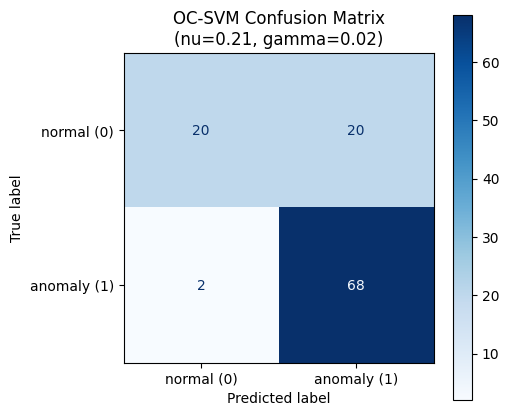

In [81]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Plot confusion matrix
cm = confusion_matrix(y_true_test, y_pred_bin, labels=[0, 1])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['normal (0)', 'anomaly (1)']
)

fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(cmap='Blues', ax=ax)
ax.set_title(f'OC-SVM Confusion Matrix\n(nu=0.21, gamma=0.02)')
plt.show()

## Part 2: Carpet Dataset

### Step 2.1: Load Train Features (good images only)

In [82]:
train_dir_carpet = r'C:\python-anomaly detection\carpet\train'
train_good_dir = os.path.join(train_dir_carpet, 'good')
train_paths = [os.path.join(train_good_dir, f) for f in os.listdir(train_good_dir) if f.endswith('.png')]
train_features_carpet = extract_deep_features(train_paths)

Extracting features: 100%|██████████| 280/280 [00:35<00:00,  7.87it/s]


### Step 2.2: Load Test Features and Labels

In [83]:
test_dir_carpet = r'C:\python-anomaly detection\carpet\test'
test_features_carpet = []
test_labels_carpet = []  # 1 for normal, -1 for anomaly
test_paths_carpet = []
img_paths_carpet = []

for subdir in os.listdir(test_dir_carpet):
    full_path = os.path.join(test_dir_carpet, subdir)
    label = 1 if subdir == 'good' else -1
    images = [os.path.join(full_path, f) for f in os.listdir(full_path) if f.endswith('.png')]
    feats = extract_deep_features(images)
    test_features_carpet.extend(feats)
    test_labels_carpet.extend([label] * len(images))
    test_paths_carpet.extend(images)
    img_paths_carpet.extend(images)

test_features_carpet = np.array(test_features_carpet)
test_labels_carpet = np.array(test_labels_carpet)

Extracting features: 100%|██████████| 19/19 [00:02<00:00,  8.63it/s]


In [84]:
# Split test set into Validation and Final Test
val_features_carpet, test_final_features_carpet, val_labels_carpet, test_final_labels_carpet, paths_val_carpet, paths_test_final_carpet = train_test_split(
    test_features_carpet, test_labels_carpet, test_paths_carpet,
    test_size=0.5,           
    stratify=test_labels_carpet,
    random_state=42
)

### Step 2.3: Predict & Evaluate

In [87]:
# Map original labels from (-1, +1) to (1, 0) with anomaly as 1 and normal as 0
true_bin = [1 if y == -1 else 0 for y in test_labels_carpet]

def evaluate_ocsvm(params, model_name="OC-SVM"):
    clf = OneClassSVM(**params)
    clf.fit(train_features_carpet)

    preds = clf.predict(test_features_carpet)          # +1 / -1
    preds_bin = [1 if p == -1 else 0 for p in preds]

    scores = -clf.decision_function(test_features_carpet)  # The larger the more anomalous

    precision, recall, _ = precision_recall_curve(true_bin, scores)
    pr_auc = auc(recall, precision)

    return {
        'Model':      model_name,
        'Accuracy':   accuracy_score(true_bin, preds_bin),
        'Precision':  precision_score(true_bin, preds_bin, zero_division=0),
        'Recall':     recall_score(true_bin, preds_bin),
        'F1 Score':   f1_score(true_bin, preds_bin),
        'ROC AUC':    roc_auc_score(true_bin, scores),
        'PR AUC':     pr_auc,
        'Params':     params,
        'Scores':     scores,
        'Model Obj':  clf
    }

# Prepare several parameter sets for comparing models
param_list_svm = [
    {'kernel': 'rbf', 'nu': 0.1, 'gamma': 'scale'},
    {'kernel': 'rbf', 'nu': 0.5,  'gamma': 'scale'},
    {'kernel': 'rbf', 'nu': 0.7,  'gamma': 'scale'},
    {'kernel': 'rbf', 'nu': 0.1,  'gamma': 0.01  },
    {'kernel': 'rbf', 'nu': 0.1,  'gamma': 0.001 },
]

results_carpet = []
for i, params in enumerate(param_list_svm, 1):
    res = evaluate_ocsvm(params, model_name=f"OC-SVM {i}")
    results_carpet.append(res)

# Display with dataframe
df_results_carpet = pd.DataFrame(results_carpet)
print(df_results_carpet[['Model','Accuracy','Precision','Recall','F1 Score','ROC AUC','PR AUC','Params']])

      Model  Accuracy  Precision    Recall  F1 Score   ROC AUC    PR AUC  \
0  OC-SVM 1  0.538462   0.807018  0.516854  0.630137  0.562199  0.826133   
1  OC-SVM 2  0.683761   0.770833  0.831461  0.800000  0.595104  0.844781   
2  OC-SVM 3  0.700855   0.759615  0.887640  0.818653  0.599920  0.846898   
3  OC-SVM 4  0.538462   0.807018  0.516854  0.630137  0.561798  0.826814   
4  OC-SVM 5  0.538462   0.807018  0.516854  0.630137  0.561396  0.825945   

                                           Params  
0  {'kernel': 'rbf', 'nu': 0.1, 'gamma': 'scale'}  
1  {'kernel': 'rbf', 'nu': 0.5, 'gamma': 'scale'}  
2  {'kernel': 'rbf', 'nu': 0.7, 'gamma': 'scale'}  
3     {'kernel': 'rbf', 'nu': 0.1, 'gamma': 0.01}  
4    {'kernel': 'rbf', 'nu': 0.1, 'gamma': 0.001}  


### Using Bayesian Optimization in Hyperparameter Tuning

In [88]:
# Use Optuna selecting parameters (nu and gamma)
def objective(trial):
    params = {
        'kernel': 'rbf',
        'nu':    trial.suggest_float('nu',   0.001, 0.9),
        'gamma': trial.suggest_float('gamma', 0.0001, 0.1)
    }
    clf = OneClassSVM(**params)
    clf.fit(train_features_carpet)
    preds = clf.predict(val_features_carpet)
    preds_bin = [1 if p == -1 else 0 for p in preds]
    true_bin = [1 if y == -1 else 0 for y in val_labels_carpet]
    trial_f1_score = f1_score(true_bin, preds_bin)
    
    return trial_f1_score

sampler = optuna.samplers.TPESampler(seed=42)
study   = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective, n_trials=30)

print("Best hyperparameters by PR AUC:", study.best_params)
print("Best PR AUC on Validation:", study.best_value)


# Add model with Optuna parameter to results
# results_carpet = []  # Clear previous results if needed
best_result = evaluate_ocsvm(study.best_params, model_name="Optuna OC-SVM")
results_carpet.append(best_result)

[I 2025-05-04 17:50:56,336] A new study created in memory with name: no-name-6729abde-c10f-4b7e-8ddf-787ef951f5cc


[I 2025-05-04 17:50:56,367] Trial 0 finished with value: 0.7441860465116279 and parameters: {'nu': 0.3377115668437789, 'gamma': 0.09507635921035062}. Best is trial 0 with value: 0.7441860465116279.
[I 2025-05-04 17:50:56,408] Trial 1 finished with value: 0.8085106382978723 and parameters: {'nu': 0.6590625536884532, 'gamma': 0.05990598257128396}. Best is trial 1 with value: 0.8085106382978723.
[I 2025-05-04 17:50:56,432] Trial 2 finished with value: 0.684931506849315 and parameters: {'nu': 0.14126075775775043, 'gamma': 0.015683852581586645}. Best is trial 1 with value: 0.8085106382978723.
[I 2025-05-04 17:50:56,448] Trial 3 finished with value: 0.647887323943662 and parameters: {'nu': 0.053217167339211315, 'gamma': 0.08663099696291603}. Best is trial 1 with value: 0.8085106382978723.
[I 2025-05-04 17:50:56,490] Trial 4 finished with value: 0.7555555555555555 and parameters: {'nu': 0.5414023955571448, 'gamma': 0.07083645052182495}. Best is trial 1 with value: 0.8085106382978723.
[I 2025-

Best hyperparameters by PR AUC: {'nu': 0.8916368329434058, 'gamma': 0.039219654585318724}
Best PR AUC on Validation: 0.8627450980392157


In [89]:
results_df_carpet = pd.DataFrame(results_carpet)
print(results_df_carpet[['Model','Accuracy','Precision','Recall','F1 Score','ROC AUC','PR AUC','Params']])

           Model  Accuracy  Precision    Recall  F1 Score   ROC AUC    PR AUC  \
0       OC-SVM 1  0.538462   0.807018  0.516854  0.630137  0.562199  0.826133   
1       OC-SVM 2  0.683761   0.770833  0.831461  0.800000  0.595104  0.844781   
2       OC-SVM 3  0.700855   0.759615  0.887640  0.818653  0.599920  0.846898   
3       OC-SVM 4  0.538462   0.807018  0.516854  0.630137  0.561798  0.826814   
4       OC-SVM 5  0.538462   0.807018  0.516854  0.630137  0.561396  0.825945   
5  Optuna OC-SVM  0.760684   0.765217  0.988764  0.862745  0.601525  0.847971   

                                              Params  
0     {'kernel': 'rbf', 'nu': 0.1, 'gamma': 'scale'}  
1     {'kernel': 'rbf', 'nu': 0.5, 'gamma': 'scale'}  
2     {'kernel': 'rbf', 'nu': 0.7, 'gamma': 'scale'}  
3        {'kernel': 'rbf', 'nu': 0.1, 'gamma': 0.01}  
4       {'kernel': 'rbf', 'nu': 0.1, 'gamma': 0.001}  
5  {'nu': 0.8916368329434058, 'gamma': 0.03921965...  


### Step 2.4: Visualize Performance

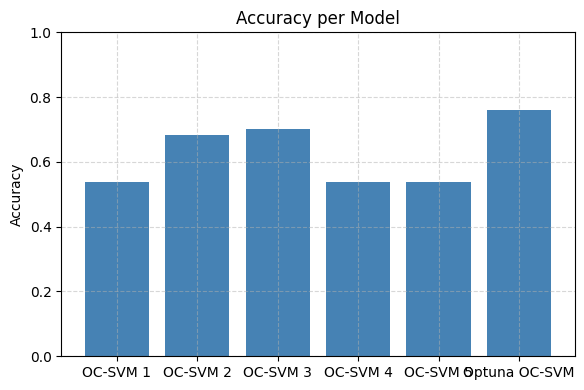

In [90]:
# Plot accuracy per Model
plt.figure(figsize=(6, 4))
plt.bar(results_df_carpet['Model'], results_df_carpet['Accuracy'], color='steelblue')
plt.title('Accuracy per Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

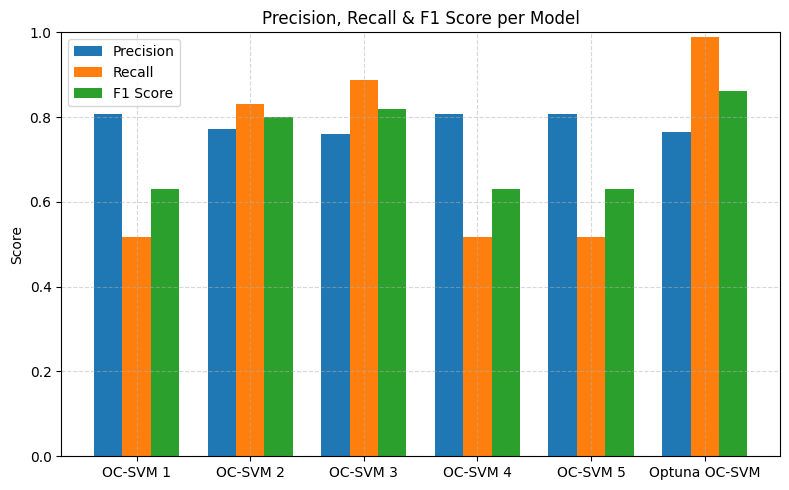

In [91]:
# Plot Precision Recall F1 per model
x = np.arange(len(results_df_carpet['Model']))
width = 0.25

plt.figure(figsize=(8, 5))
plt.bar(x - width, results_df_carpet['Precision'], width=width, label='Precision')
plt.bar(x, results_df_carpet['Recall'], width=width, label='Recall')
plt.bar(x + width, results_df_carpet['F1 Score'], width=width, label='F1 Score')

plt.xticks(x, results_df_carpet['Model'])
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Precision, Recall & F1 Score per Model')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

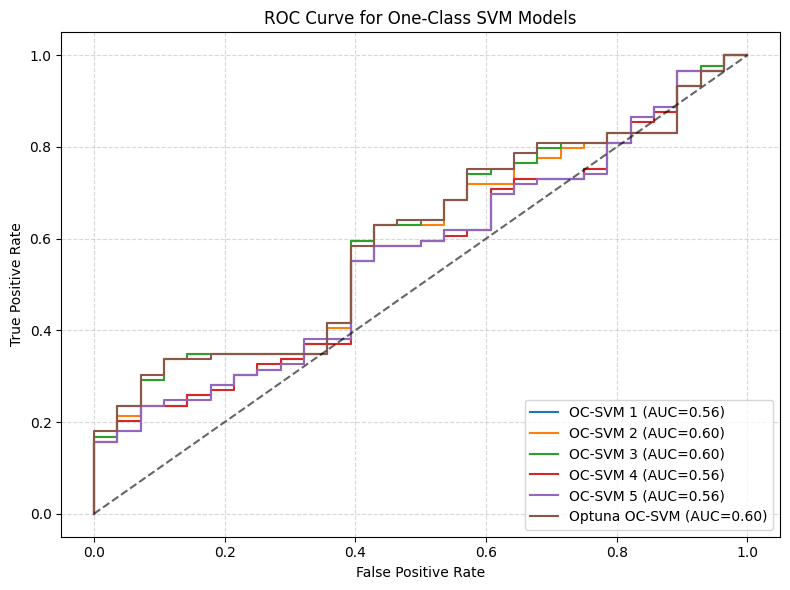

In [92]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import OneClassSVM
from sklearn.metrics import roc_curve, roc_auc_score

roc_curves = []

for idx, row in results_df_carpet.iterrows():
    params     = row['Params']      # {'nu':..., 'gamma':...}
    model_name = row['Model']       # e.g. "OC-SVM 1"

    clf = OneClassSVM(**params)
    clf.fit(train_features_carpet)

    scores = -clf.decision_function(test_features_carpet)

    fpr, tpr, _   = roc_curve(true_bin, scores)
    auc_score     = roc_auc_score(true_bin, scores)

    roc_curves.append((f"{model_name} (AUC={auc_score:.2f})", fpr, tpr))

# Plot ROC Curve for each model
plt.figure(figsize=(8, 6))
for label, fpr, tpr in roc_curves:
    plt.plot(fpr, tpr, label=label)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.6)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for One-Class SVM Models')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

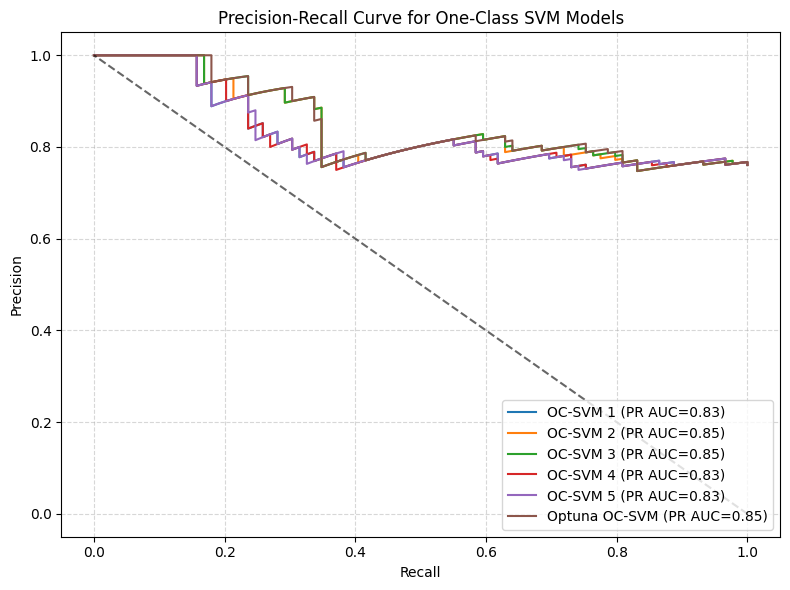

In [93]:
from sklearn.metrics import precision_recall_curve, average_precision_score

pr_curves = []

for idx, row in results_df_carpet.iterrows():
    params     = row['Params']      # {'nu':..., 'gamma':...}
    model_name = row['Model']       # e.g. "OC-SVM 1"

    clf = OneClassSVM(**params)
    clf.fit(train_features_carpet)

    scores = -clf.decision_function(test_features_carpet)

    precision, recall, _   = precision_recall_curve(true_bin, scores)
    pr_auc_score     = average_precision_score(true_bin, scores)

    pr_curves.append((f"{model_name} (PR AUC={pr_auc_score:.2f})", recall, precision))

# Plot PR Curve for each model
plt.figure(figsize=(8, 6))
for label, recall, precision in pr_curves:
    plt.plot(recall, precision, label=label)

plt.plot([1, 0], [0, 1], 'k--', alpha=0.6)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for One-Class SVM Models')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [94]:
from sklearn.svm import OneClassSVM
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, auc

# Extract the best parameters suggested by Optuna
best_params = study.best_params
print("Best params from Optuna:", best_params)

# Use best parameters to train the model
final_clf = OneClassSVM(**best_params)
final_clf.fit(train_features_carpet)  

# Use the model to make predictions on final test set 
y_pred_test = final_clf.predict(test_features_carpet)          # +1 / -1
y_pred_bin  = [1 if p == -1 else 0 for p in y_pred_test]  

scores_test = -final_clf.decision_function(test_features_carpet)

# Print classification report
print("=== Final Test Classification Report ===")
print(classification_report(
    [1 if y==-1 else 0 for y in test_labels_carpet],  
    y_pred_bin,
    zero_division=0
))

# Print ROC AUC
y_true_test = [1 if y==-1 else 0 for y in test_labels_carpet]
test_roc_auc = roc_auc_score(y_true_test, scores_test)
print(f"Final Test ROC AUC = {test_roc_auc:.2f}")

# Print PR AUC
prec_vals, rec_vals, _ = precision_recall_curve(y_true_test, scores_test)
pr_auc = auc(rec_vals, prec_vals)
print(f"Final Test PR  AUC = {pr_auc:.2f}")

Best params from Optuna: {'nu': 0.8916368329434058, 'gamma': 0.039219654585318724}
=== Final Test Classification Report ===
              precision    recall  f1-score   support

           0       0.50      0.04      0.07        28
           1       0.77      0.99      0.86        89

    accuracy                           0.76       117
   macro avg       0.63      0.51      0.46       117
weighted avg       0.70      0.76      0.67       117

Final Test ROC AUC = 0.60
Final Test PR  AUC = 0.85


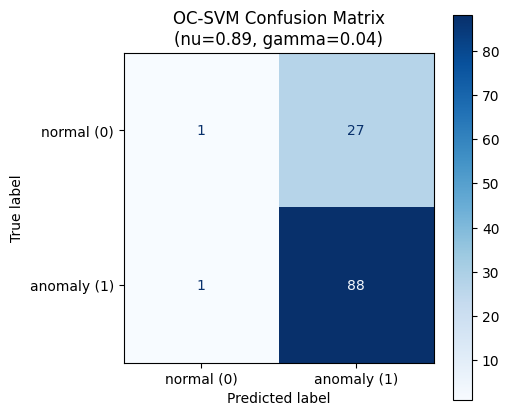

In [95]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Plot confusion matrix
cm = confusion_matrix(y_true_test, y_pred_bin, labels=[0, 1])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['normal (0)', 'anomaly (1)']
)

fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(cmap='Blues', ax=ax)
ax.set_title(f'OC-SVM Confusion Matrix\n(nu=0.89, gamma=0.04)')
plt.show()